# Project Name
Mental Health in Tech Industry – Exploratory Data Analysis

##### Project Type
EDA

##### Contribution
Individual

##### Team Member 1 - Suyash Labhane
##### Team Member 2 - NA
##### Team Member 3 - NA
##### Team Member 4 - NA


# Project Summary

This project analyzes the Mental Health in Tech Survey dataset to understand workplace attitudes toward mental health in the tech industry. The goal is to explore treatment behavior, company support systems, and stigma related to mental health discussions.

Using Exploratory Data Analysis (EDA), we perform Univariate, Bivariate, and Multivariate analysis to identify patterns and key influencing factors. The findings will help organizations improve mental health awareness, benefits, and workplace policies.


# Problem Statement

Mental health issues are common in the tech industry, but stigma and lack of awareness prevent employees from seeking treatment. Companies need data-driven insights to improve workplace mental health policies.


# Business Objective

The objective is to identify key factors influencing mental health treatment and workplace attitudes, and provide actionable recommendations to improve employee well-being.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("survey.csv")

In [4]:
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
df.shape

(1259, 27)

In [6]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

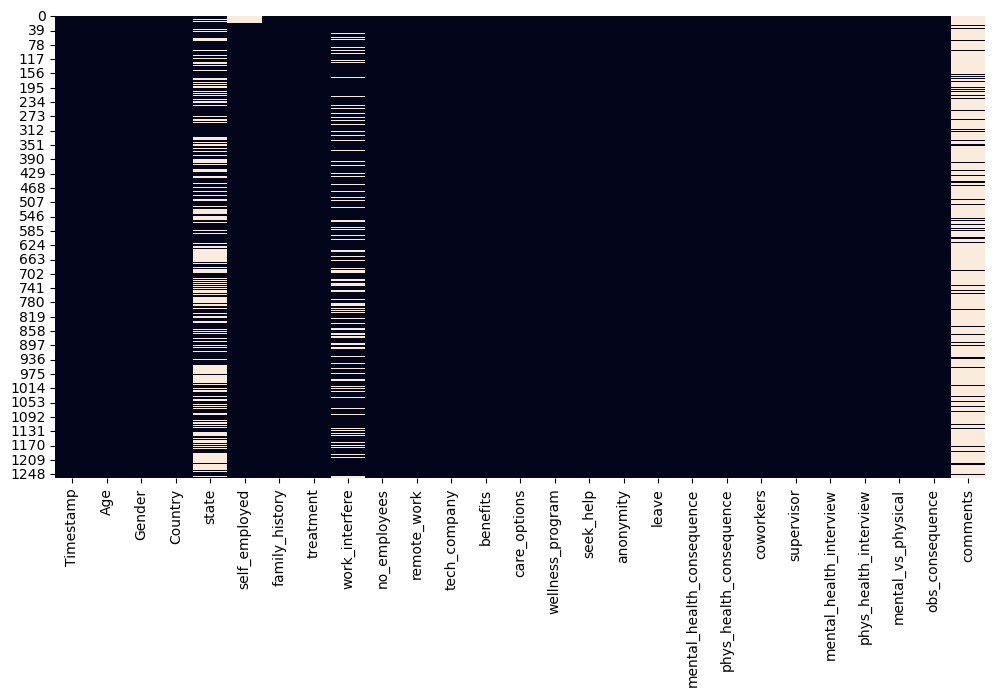

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [11]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


### What did you know about your dataset?

- The dataset contains ____ rows and ____ columns.
- There are missing values in some columns.
- Some variables are categorical (like Gender, Country, Treatment).
- Some variables are numerical (like Age).
- Data cleaning will be required before visualization.


In [12]:
df['Age'].describe()


count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [13]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 60)]


In [14]:
df['Gender'].unique()


array(['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile',
       'Trans-female', 'Cis Female', 'F', 'something kinda male?',
       'Cis Male', 'Woman', 'f', 'Mal', 'Male (CIS)', 'queer/she/they',
       'non-binary', 'Femake', 'woman', 'Make', 'Nah', 'Enby', 'fluid',
       'Genderqueer', 'Female ', 'Androgyne', 'Agender',
       'cis-female/femme', 'Guy (-ish) ^_^', 'male leaning androgynous',
       'Male ', 'Man', 'Trans woman', 'msle', 'Neuter', 'Female (trans)',
       'queer', 'Female (cis)', 'Mail', 'cis male', 'Malr', 'femail',
       'Cis Man', 'ostensibly male, unsure what that really means'],
      dtype=object)

In [15]:
df['Gender'] = df['Gender'].str.lower()

In [16]:
df['Gender'] = df['Gender'].replace({
    'male': 'Male',
    'm': 'Male',
    'man': 'Male',
    'female': 'Female',
    'f': 'Female',
    'woman': 'Female'
})

In [17]:
df.loc[~df['Gender'].isin(['Male', 'Female']), 'Gender'] = 'Other'

In [18]:
df['Gender'].value_counts()

Gender
Male      965
Female    239
Other      43
Name: count, dtype: int64

In [19]:
df.drop(['Timestamp', 'comments'], axis=1, inplace=True)

In [20]:
df.isnull().sum()

Age                            0
Gender                         0
Country                        0
state                        512
self_employed                 18
family_history                 0
treatment                      0
work_interfere               261
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                   0
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequence                0
dtype: int64

In [21]:
df.fillna('Not Specified', inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1247 entries, 0 to 1258
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1247 non-null   int64 
 1   Gender                     1247 non-null   object
 2   Country                    1247 non-null   object
 3   state                      1247 non-null   object
 4   self_employed              1247 non-null   object
 5   family_history             1247 non-null   object
 6   treatment                  1247 non-null   object
 7   work_interfere             1247 non-null   object
 8   no_employees               1247 non-null   object
 9   remote_work                1247 non-null   object
 10  tech_company               1247 non-null   object
 11  benefits                   1247 non-null   object
 12  care_options               1247 non-null   object
 13  wellness_program           1247 non-null   object
 14  seek_help    

### What all manipulations have you done and insights you found?

- Removed unrealistic age values.
- Standardized gender column into Male, Female, and Other.
- Dropped unnecessary columns like Timestamp and comments.
- Handled missing values using appropriate techniques.
- Data is now cleaned and ready for visualization.


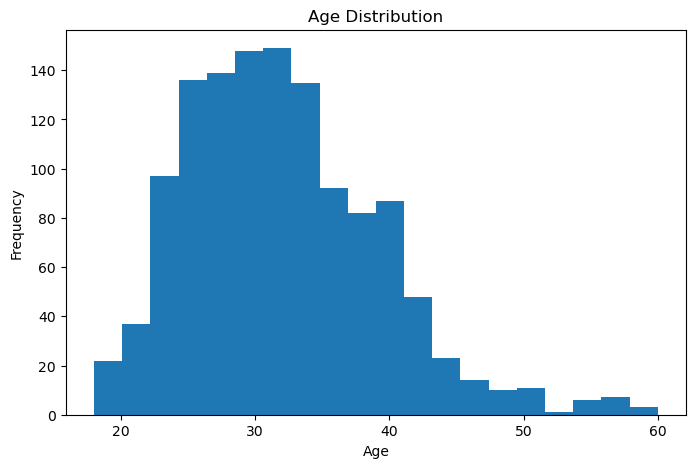

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Chart 1: Age Distribution

1. Why did you pick this chart?
Histogram is used to understand the distribution of a numerical variable like Age.

2. What insights were found?
Most respondents belong to the age group of 25–35 years. Very few respondents are above 50 years.

3. Business Impact:
The tech workforce is dominated by young professionals. Mental health policies should focus more on young and mid-career employees.


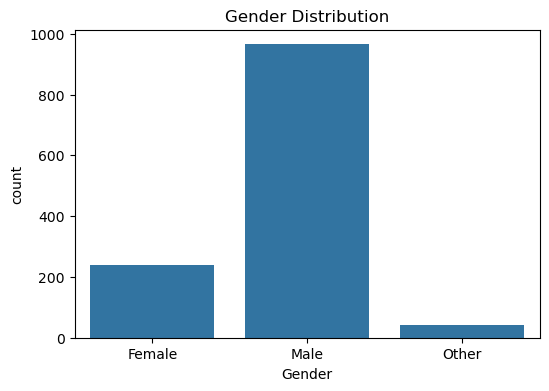

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()


### Chart 2: Gender Distribution

1. Why this chart?
Countplot helps visualize frequency of categorical data.

2. Insights:
Most respondents are Male. Female participation is lower, and Other category is very small.

3. Business Impact:
Tech industry is male-dominated. Companies should ensure inclusive mental health policies.


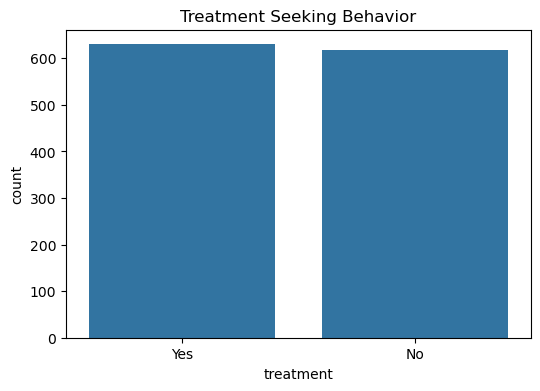

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='treatment', data=df)
plt.title('Treatment Seeking Behavior')
plt.show()


### Chart 3: Treatment Seeking Behavior

1. Why this chart?
To understand how many employees have sought mental health treatment.

2. Insights:
A significant portion of employees have sought treatment.

3. Business Impact:
Mental health conditions are common. Organizations must provide structured support systems.


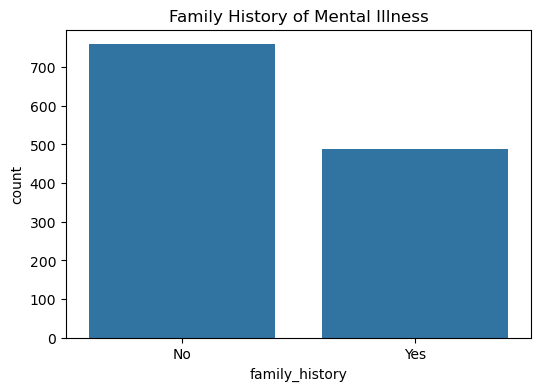

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='family_history', data=df)
plt.title('Family History of Mental Illness')
plt.show()


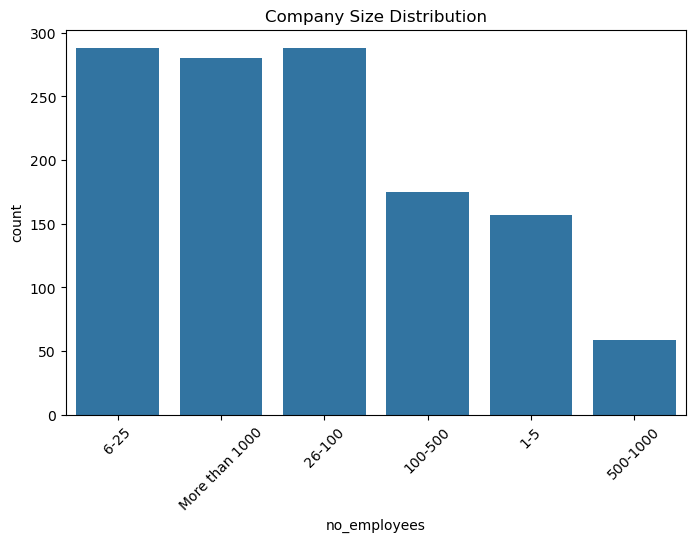

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='no_employees', data=df)
plt.xticks(rotation=45)
plt.title('Company Size Distribution')
plt.show()


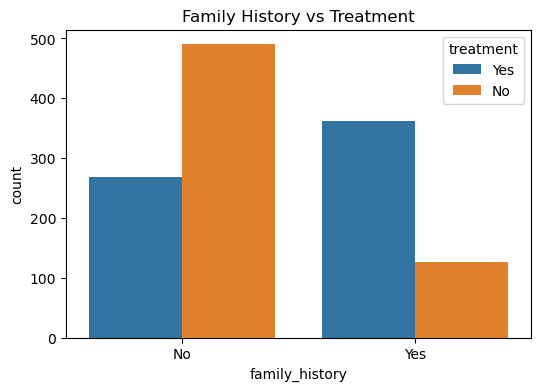

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title('Family History vs Treatment')
plt.show()


### Chart 6: Family History vs Treatment

1. Why this chart?
To analyze whether having a family history of mental illness influences treatment seeking behavior.

2. Insights:
People with a family history of mental illness are more likely to seek treatment.

3. Business Impact:
Employees with a family history may require proactive mental health support programs.


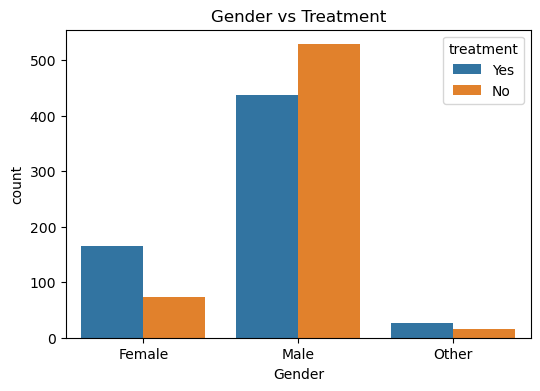

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title('Gender vs Treatment')
plt.show()


### Chart 7: Gender vs Treatment

1. Why this chart?
To check if treatment seeking differs by gender.

2. Insights:
Treatment patterns may vary across genders.

3. Business Impact:
Gender-sensitive mental health programs may improve engagement.


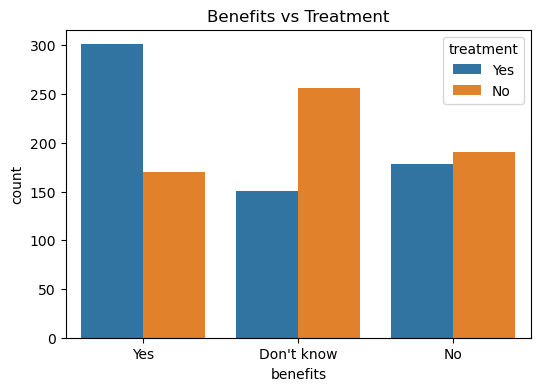

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='benefits', hue='treatment', data=df)
plt.title('Benefits vs Treatment')
plt.show()


### Chart 8: Benefits vs Treatment

1. Why this chart?
To analyze if employer-provided benefits influence treatment seeking.

2. Insights:
Employees with mental health benefits are more likely to seek treatment.

3. Business Impact:
Providing mental health benefits encourages employees to seek help.


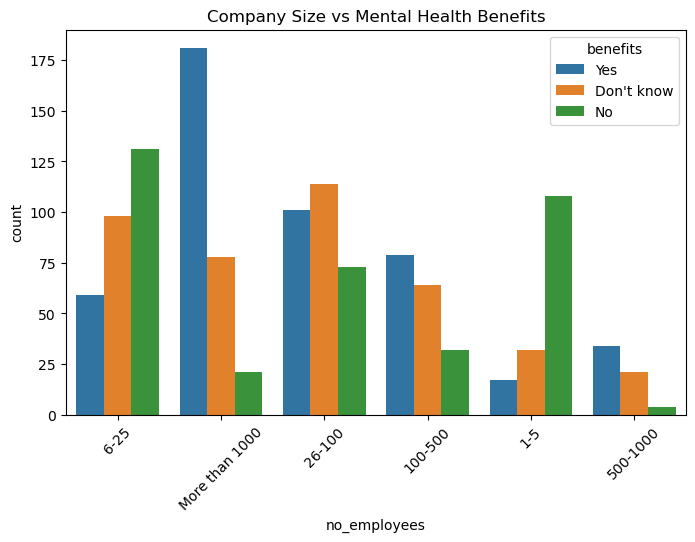

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='no_employees', hue='benefits', data=df)
plt.xticks(rotation=45)
plt.title('Company Size vs Mental Health Benefits')
plt.show()


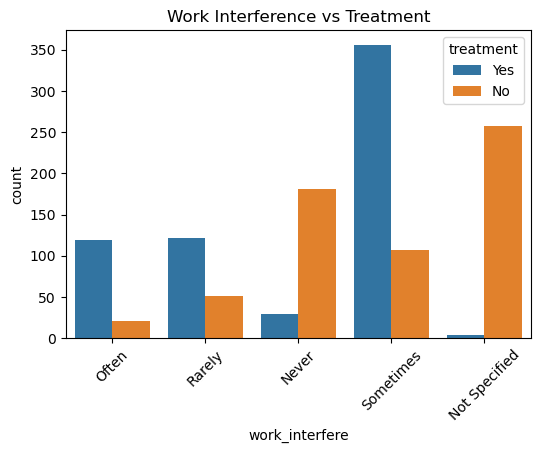

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='work_interfere', hue='treatment', data=df)
plt.xticks(rotation=45)
plt.title('Work Interference vs Treatment')
plt.show()


In [33]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])


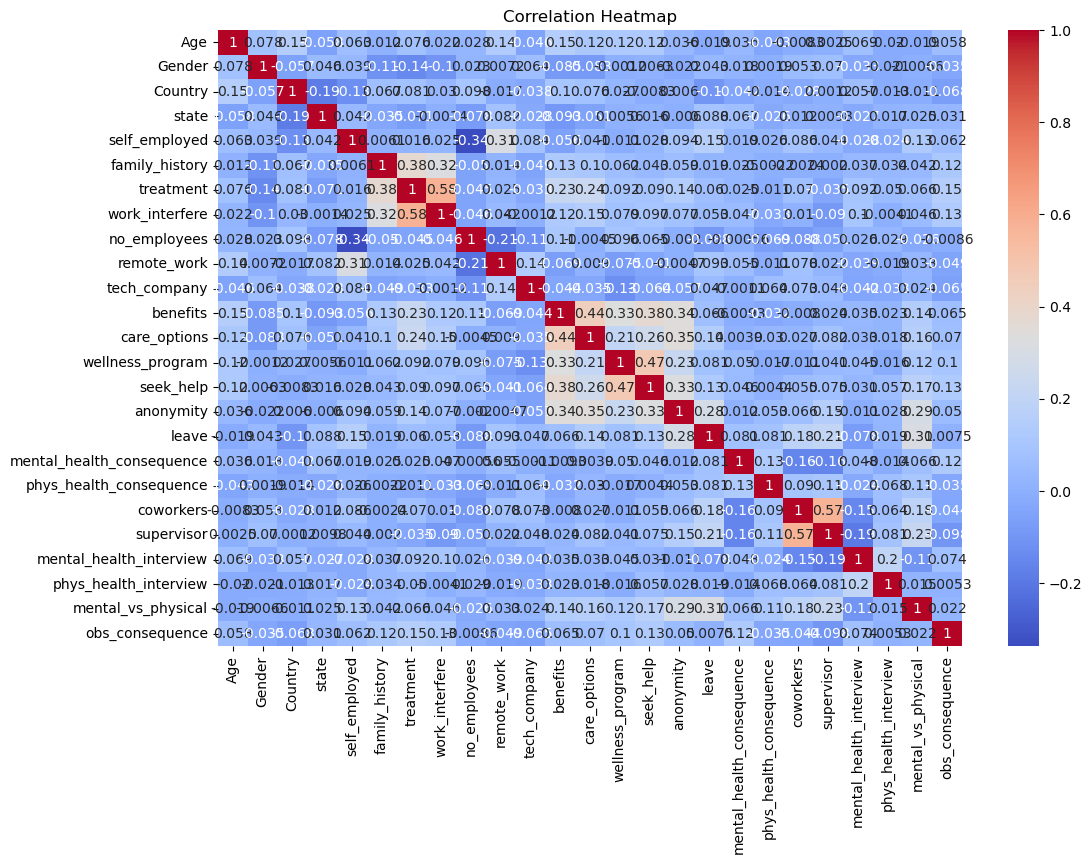

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### Chart 11: Correlation Heatmap

1. Why this chart?
To understand relationships between multiple variables at once.

2. Insights:
Family history and treatment show strong positive correlation.
Benefits and treatment also show relationship.

3. Business Impact:
Identifying strong predictors helps companies design targeted mental health policies.


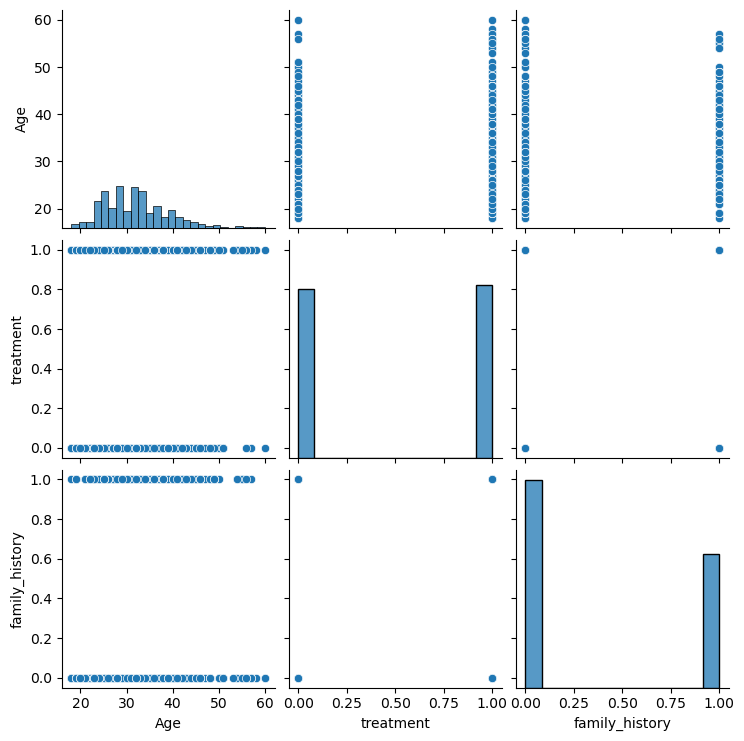

In [35]:
sns.pairplot(df_encoded[['Age','treatment','family_history']])
plt.show()


### Chart 12: Pair Plot

1. Why this chart?
To visualize pairwise relationships between important variables.

2. Insights:
Treatment patterns vary across age groups and family history.

3. Business Impact:
Helps in identifying risk groups based on age and background.


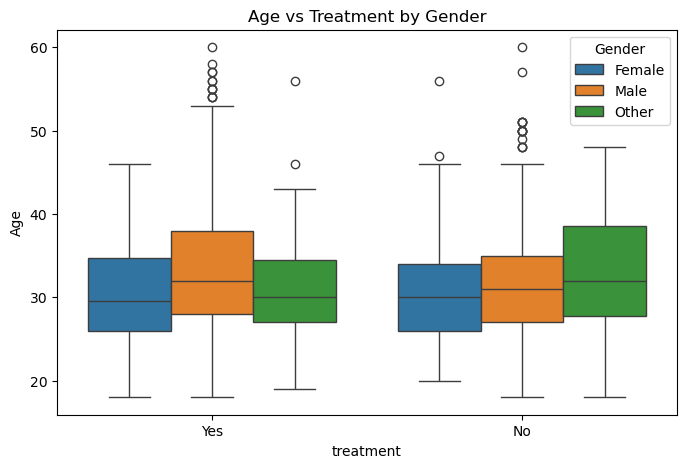

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='treatment', y='Age', hue='Gender', data=df)
plt.title('Age vs Treatment by Gender')
plt.show()


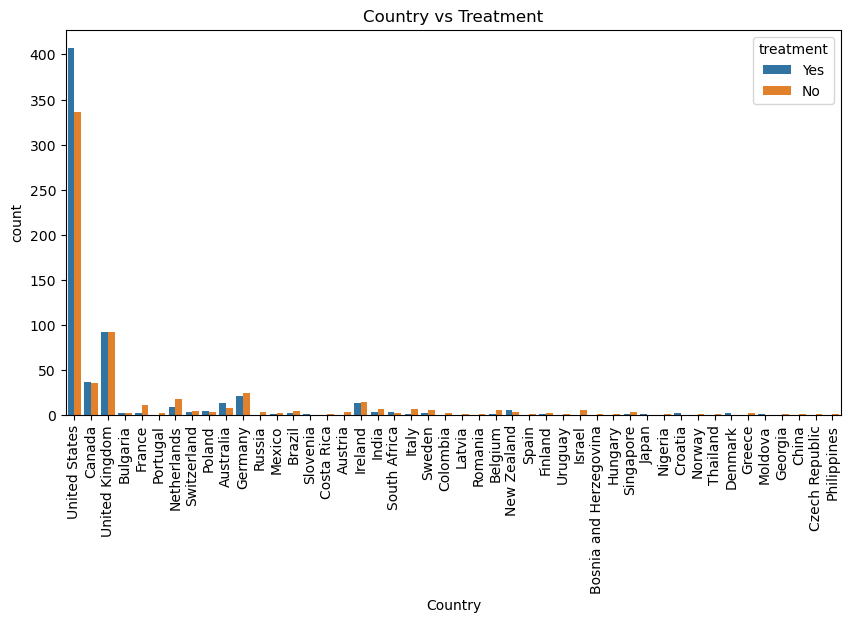

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(x='Country', hue='treatment', data=df)
plt.xticks(rotation=90)
plt.title('Country vs Treatment')
plt.show()


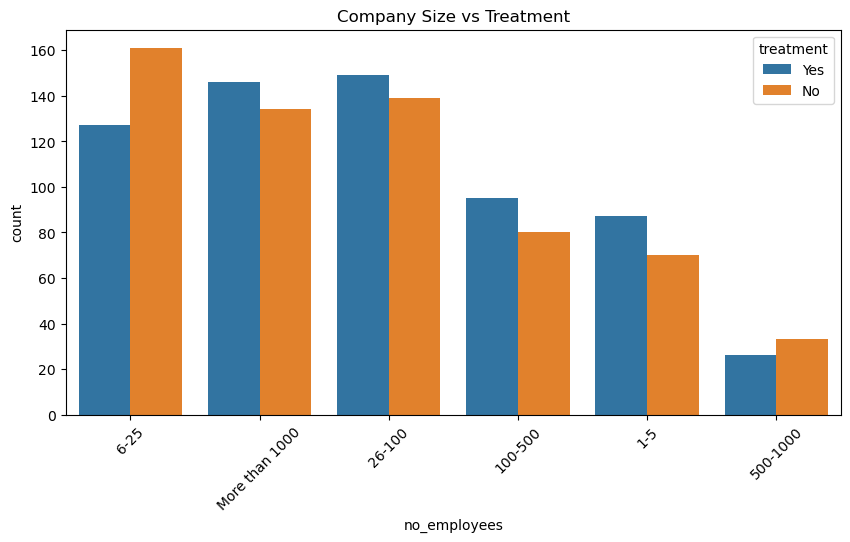

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(x='no_employees', hue='treatment', data=df)
plt.xticks(rotation=45)
plt.title('Company Size vs Treatment')
plt.show()


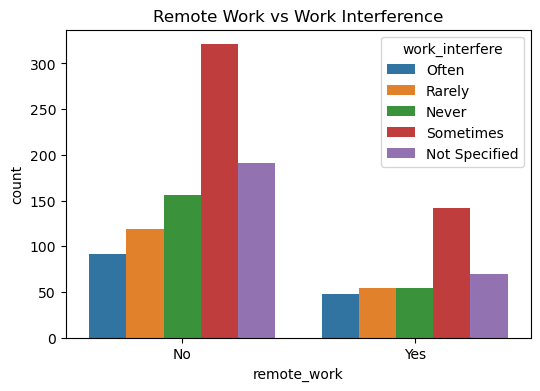

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x='remote_work', hue='work_interfere', data=df)
plt.title('Remote Work vs Work Interference')
plt.show()


### Chart 16: Remote Work vs Work Interference

1. Why this chart?
To understand whether remote work affects mental health interference.

2. Insights:
Employees working remotely may report different levels of work interference.

3. Business Impact:
Flexible work policies can influence mental well-being.


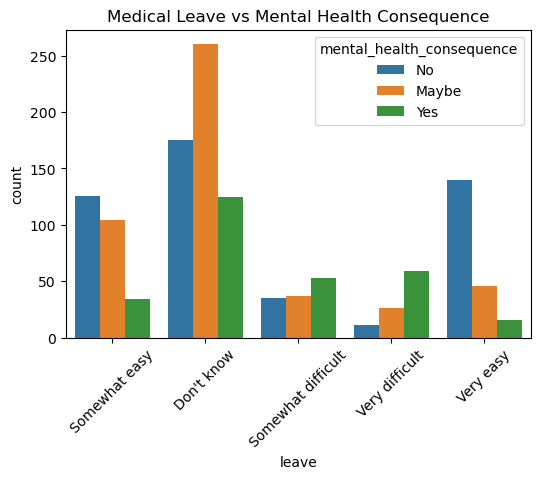

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='leave', hue='mental_health_consequence', data=df)
plt.xticks(rotation=45)
plt.title('Medical Leave vs Mental Health Consequence')
plt.show()


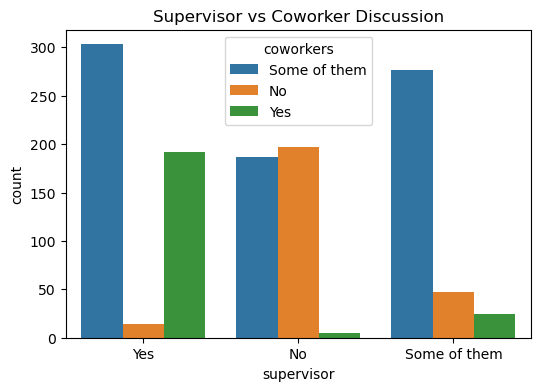

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='supervisor', hue='coworkers', data=df)
plt.title('Supervisor vs Coworker Discussion')
plt.show()


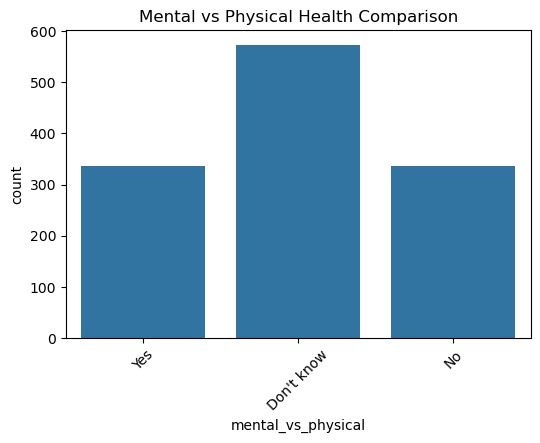

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='mental_vs_physical', data=df)
plt.xticks(rotation=45)
plt.title('Mental vs Physical Health Comparison')
plt.show()

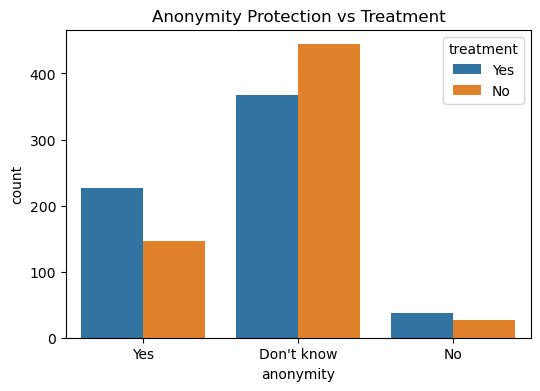

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='anonymity', hue='treatment', data=df)
plt.title('Anonymity Protection vs Treatment')
plt.show()

## Solution to Business Objective

- Companies should provide structured mental health benefits.
- Awareness programs should be conducted regularly.
- Anonymity protection must be ensured.
- Encourage open discussions with supervisors.
- Flexible work policies may reduce mental health interference.


# Conclusion

The analysis reveals that mental health issues are common in the tech industry. Family history, workplace benefits, company size, and openness in discussion significantly influence treatment seeking behavior.

Organizations that provide mental health benefits and ensure anonymity create a more supportive environment. Data-driven policies can improve employee well-being, productivity, and retention.
